# Python for CFD and AI in Fluids  

<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week01/01_python_for_cfd_ai_fluids.ipynb)
## A beginner-friendly bridge from programming to fluid-flow computations

This notebook is the **first programming file** for the course **AI in Fluids**.

The goal is not to solve a difficult CFD problem immediately. The goal is to help you understand the programming language and numerical ideas that appear later in CFD and machine learning codes.

Many students can press **Run all**, but that does not mean they understand the code.  
In this notebook, every important Python command is connected to a CFD idea.

| Python idea | Why it matters in CFD | Why it matters in AI |
|---|---|---|
| variables | store physical parameters such as velocity, length, viscosity | store hyperparameters such as learning rate and number of epochs |
| `if` statements | check stability, choose boundary conditions, stop when converged | choose model options, stop training, handle bad data |
| `for` loops | march in time, loop over grid points, compute residuals | loop over epochs or batches |
| arrays | store velocity, pressure, temperature fields | store tensors, images, features, labels |
| functions | organize solvers into reusable pieces | organize models, loss functions, training steps |
| finite differences | approximate derivatives in PDEs | appear in physics-informed losses and residuals |
| residuals | measure whether equations are satisfied | measure loss/error during training |

By the end of this notebook, you should be able to read a simple CFD code and understand:
1. what the variables mean,
2. what arrays represent,
3. why loops are used,
4. how finite differences approximate derivatives,
5. how residuals measure convergence,
6. why this is the same programming style used later in AI models for fluids.

We will use only standard Python, NumPy, and Matplotlib.

## 0. How to use this notebook

Do not only run the cells. For each code block:

1. Read the explanation above the code.
2. Predict what the code will do.
3. Run the code.
4. Change one number.
5. Run it again.
6. Write one sentence explaining what changed.

This is exactly how CFD debugging works. A CFD solver is not a black box.  
A CFD solver is a sequence of small operations: define variables, build a grid, compute derivatives, update fields, apply boundary conditions, and check residuals.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week01"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

# Standard packages for this notebook.
# NumPy is the main array/tensor library used in scientific Python.
# Matplotlib is used for plotting fields, profiles, and convergence curves.

import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.3.5


## 1. Python as a scientific calculator

Before solving a PDE, Python must be able to store and compute physical quantities.

A **variable** is a name attached to a value.  
In CFD, variables often represent physical parameters:

- `rho`: density $\rho$
- `U`: characteristic velocity $U$
- `L`: characteristic length $L$
- `mu`: dynamic viscosity $\mu$
- `nu`: kinematic viscosity $\nu=\mu/\rho$
- `Re`: Reynolds number $Re=UL/\nu$

The Reynolds number compares inertial transport with viscous diffusion.  
It is one of the first dimensionless numbers students should recognize in fluid mechanics.

In [2]:
# A small fluid-mechanics calculation using Python variables.

rho = 1.0       # density, kg/m^3
U = 1.0         # characteristic velocity, m/s
L = 1.0         # characteristic length, m
nu = 0.01       # kinematic viscosity, m^2/s

Re = U * L / nu

print("Density rho =", rho)
print("Velocity U  =", U)
print("Length L    =", L)
print("Viscosity nu=", nu)
print("Reynolds number Re =", Re)

Density rho = 1.0
Velocity U  = 1.0
Length L    = 1.0
Viscosity nu= 0.01
Reynolds number Re = 100.0


### Important Python habit: print with context

A beginner often writes:

```python
print(Re)
```

This prints a number, but it does not explain what the number means.  
A better habit is:

```python
print(f"Reynolds number = {Re:.1f}")
```

The `f` before the string means **formatted string**.  
The expression `{Re:.1f}` means: insert the value of `Re` with one digit after the decimal point.

In [3]:
print(f"Reynolds number = {Re:.1f}")
print(f"Kinematic viscosity = {nu:.4e} m^2/s")

Reynolds number = 100.0
Kinematic viscosity = 1.0000e-02 m^2/s


### Try it

Change `nu` from `0.01` to `0.001`.  
What happens to the Reynolds number?  

Expected explanation:

> Smaller viscosity makes Reynolds number larger, so inertia becomes more important relative to viscous diffusion.

## 2. Data types: numbers, strings, and booleans

Python values have types.

Common types in CFD codes:

| Type | Example | CFD meaning |
|---|---|---|
| `int` | `N = 65` | number of grid points |
| `float` | `dt = 0.001` | time step |
| `str` | `"cavity"` | case name |
| `bool` | `plot = True` | turn a feature on/off |

You should always know whether a variable is a number, text, or logical flag.

In [4]:
N = 65
dt = 0.001
case_name = "lid-driven cavity"
make_plots = True

print(type(N), N)
print(type(dt), dt)
print(type(case_name), case_name)
print(type(make_plots), make_plots)

<class 'int'> 65
<class 'float'> 0.001
<class 'str'> lid-driven cavity
<class 'bool'> True


## 3. Conditions: `if`, `elif`, and `else`

CFD codes constantly make decisions.

Examples:

- If the Reynolds number is small, the flow is likely smooth.
- If the residual is below tolerance, stop iterating.
- If a grid point is on a wall, apply a boundary condition.
- If the time step is too large, warn the user.

The basic structure is:

```python
if condition:
    do something
elif another_condition:
    do something else
else:
    default action
```

Indentation is part of Python syntax. Code inside an `if` block must be indented.

In [5]:
Re = 100

if Re < 1:
    regime = "creeping or Stokes-like flow"
elif Re < 1000:
    regime = "laminar flow is expected for many simple internal benchmarks"
else:
    regime = "inertia is strong; instabilities or turbulence may appear depending on geometry"

print(f"Re = {Re}")
print("Estimated regime:", regime)

Re = 100
Estimated regime: laminar flow is expected for many simple internal benchmarks


### Conditions for numerical safety

A very common CFD pattern is to check whether a numerical parameter is safe.  
For an explicit diffusion update, a simplified stability condition is

$$
\Delta t \le C \frac{\Delta x^2}{\nu}.
$$

The exact constant depends on the equation and discretization.  
The important programming idea is that a CFD code should **check** stability instead of silently producing nonsense.

In [6]:
dx = 1.0 / (N - 1)
nu = 0.01
dt = 0.001

stability_limit = 0.5 * dx**2 / nu

print(f"dx = {dx:.5f}")
print(f"dt = {dt:.5e}")
print(f"estimated stability limit = {stability_limit:.5e}")

if dt <= stability_limit:
    print("Time step looks safe for this simple diffusion estimate.")
else:
    print("WARNING: time step may be too large.")

dx = 0.01562
dt = 1.00000e-03
estimated stability limit = 1.22070e-02
Time step looks safe for this simple diffusion estimate.


### Exercise: write your own condition

Write an `if` statement that prints:

- `"coarse grid"` if `N < 50`
- `"medium grid"` if `50 <= N < 150`
- `"fine grid"` if `N >= 150`

This is not just a Python exercise. CFD reports often compare coarse, medium, and fine grids.

In [7]:
# Student exercise:
N = 65

# TODO: complete this block
if N < 50:
    grid_type = "coarse grid"
elif N < 150:
    grid_type = "medium grid"
else:
    grid_type = "fine grid"

print(f"N = {N}: {grid_type}")

N = 65: medium grid


## 4. Lists, tuples, and dictionaries

CFD simulations usually store many settings.

A **list** is an ordered collection that can be changed.  
A **tuple** is an ordered collection usually treated as fixed.  
A **dictionary** maps names to values.

Dictionaries are very useful for simulation parameters because they make code readable.

In [8]:
# A list of grid sizes
grid_sizes = [33, 65, 129]

# A tuple for a 2D velocity vector
lid_velocity = (1.0, 0.0)

# A dictionary for a CFD case
case = {
    "name": "Ghia cavity warmup",
    "Re": 100,
    "N": 65,
    "dt": 0.001,
    "steps": 15000,
    "method": "finite difference"
}

print("Grid sizes:", grid_sizes)
print("Lid velocity:", lid_velocity)
print("Case dictionary:", case)
print("The Reynolds number is", case["Re"])

Grid sizes: [33, 65, 129]
Lid velocity: (1.0, 0.0)
Case dictionary: {'name': 'Ghia cavity warmup', 'Re': 100, 'N': 65, 'dt': 0.001, 'steps': 15000, 'method': 'finite difference'}
The Reynolds number is 100


### Why dictionaries matter

Compare these two lines:

```python
run(100, 65, 0.001, 15000)
```

and

```python
run(Re=100, N=65, dt=0.001, steps=15000)
```

The second one is easier to read. In CFD and machine learning, readability prevents mistakes.

## 5. Loops: repeating an operation

A CFD solver repeats operations many times.

Examples:

- repeat time steps,
- repeat Jacobi iterations for a Poisson equation,
- loop over grid points,
- loop over epochs in machine learning.

The simplest loop is a `for` loop.

In [9]:
# A simple for loop.
for step in range(5):
    print("step =", step)

step = 0
step = 1
step = 2
step = 3
step = 4


`range(5)` produces the numbers `0, 1, 2, 3, 4`.

Python indexing starts from zero.  
This is important because arrays also start from index zero.

In [10]:
# A loop that mimics residual decay.
residual = 1.0

for iteration in range(10):
    residual = 0.6 * residual
    print(f"iteration {iteration:02d}: residual = {residual:.4e}")

iteration 00: residual = 6.0000e-01
iteration 01: residual = 3.6000e-01
iteration 02: residual = 2.1600e-01
iteration 03: residual = 1.2960e-01
iteration 04: residual = 7.7760e-02
iteration 05: residual = 4.6656e-02
iteration 06: residual = 2.7994e-02
iteration 07: residual = 1.6796e-02
iteration 08: residual = 1.0078e-02
iteration 09: residual = 6.0466e-03


### `while` loops and convergence

A `while` loop repeats until a condition becomes false.

This is closer to how many CFD solvers work:

```python
while residual > tolerance:
    update_solution()
    compute_residual()
```

A solver should not stop just because it has completed a fixed number of steps.  
It should ideally stop because the residual is small enough.
For a steady iterative solve, a residual can control stopping. A transient simulation instead advances to a specified physical time; its changing solution need not have a small time-step update.


In [11]:
residual = 1.0
tolerance = 1e-3
iteration = 0
max_iterations = 100

while residual > tolerance and iteration < max_iterations:
    residual *= 0.7
    iteration += 1

print("Stopped at iteration:", iteration)
print(f"Final residual = {residual:.3e}")

if residual <= tolerance:
    print("Converged.")
else:
    print("Stopped because maximum iterations was reached.")

Stopped at iteration: 20
Final residual = 7.979e-04
Converged.


## 6. Functions: reusable blocks of code

A function takes inputs and returns outputs.  
Functions make CFD codes easier to read and test.

Instead of writing the Reynolds number formula everywhere, define it once.

In [12]:
def reynolds_number(U, L, nu):
    # Compute Reynolds number Re = U L / nu.
    return U * L / nu

print(reynolds_number(U=1.0, L=1.0, nu=0.01))

100.0


### Functions should be small and testable

A good CFD code is not one giant block.  
A good CFD code contains small functions such as:

- `build_grid`
- `apply_boundary_conditions`
- `compute_laplacian`
- `compute_residual`
- `plot_centerline_velocity`

Small functions are easier to debug and easier to reuse in AI workflows.

In [13]:
def classify_reynolds(Re):
    # Return a short qualitative description of the flow regime.
    if Re < 1:
        return "creeping-flow regime"
    elif Re < 1000:
        return "laminar benchmark regime"
    else:
        return "high-Re regime; instabilities may matter"

for Re_test in [0.1, 100, 5000]:
    print(f"Re = {Re_test:7.1f}: {classify_reynolds(Re_test)}")

Re =     0.1: creeping-flow regime
Re =   100.0: laminar benchmark regime
Re =  5000.0: high-Re regime; instabilities may matter


## 7. NumPy arrays: fields on a grid

In CFD, a field is a quantity defined at many points:

- $u(x,y)$: horizontal velocity
- $v(x,y)$: vertical velocity
- $p(x,y)$: pressure
- $T(x,y)$: temperature
- $\omega(x,y)$: vorticity

On a computer, a field becomes an array.

For a two-dimensional grid, we usually store data in an array with shape:

```python
(Ny, Nx)
```

The first index is the row or $y$-direction.  
The second index is the column or $x$-direction.

So `u[j, i]` means the value at $y_j, x_i$.

In [14]:
Nx = 65
Ny = 65

x = np.linspace(0.0, 1.0, Nx)
y = np.linspace(0.0, 1.0, Ny)

X, Y = np.meshgrid(x, y)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

x shape: (65,)
y shape: (65,)
X shape: (65, 65)
Y shape: (65, 65)


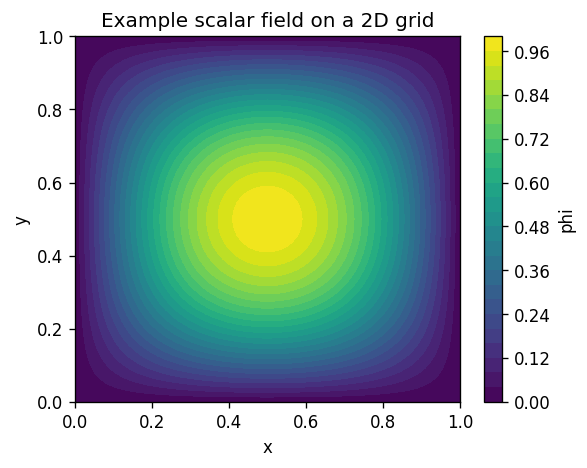

In [15]:
# Create a smooth scalar field.
phi = np.sin(np.pi * X) * np.sin(np.pi * Y)

plt.figure(figsize=(5, 4))
plt.contourf(X, Y, phi, levels=30)
plt.colorbar(label="phi")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Example scalar field on a 2D grid")
plt.tight_layout()
plt.show()

### Why this matters for machine learning

A 2D CFD field is like an image:

- an image has pixels,
- a CFD field has grid values.

A CNN, U-Net, or neural operator sees a CFD field as a tensor.  
This is why learning arrays carefully is essential before using AI in fluids.

## 8. Indexing and slicing

Slicing means selecting part of an array.

Examples:

- `u[0, :]` = bottom row
- `u[-1, :]` = top row
- `u[:, 0]` = left column
- `u[:, -1]` = right column
- `u[1:-1, 1:-1]` = interior points

Boundary conditions in CFD are often implemented with slicing.

Bottom wall average u: 0.0
Top wall interior average u   : 1.0
Interior average u   : 0.0


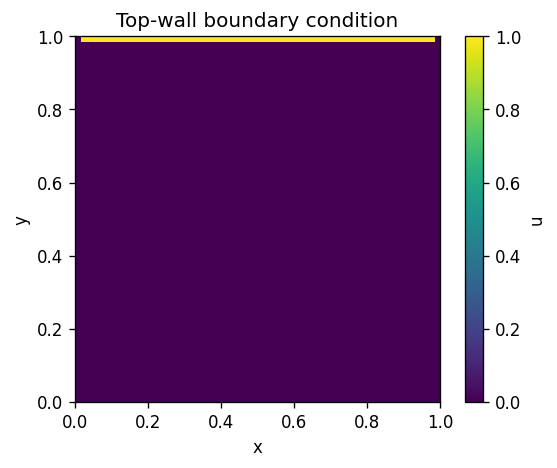

In [16]:
u = np.zeros((Ny, Nx))

# Lid-driven cavity boundary condition:
# top wall moves with u = 1, all other walls have u = 0.
u[-1, 1:-1] = 1.0  # stationary side walls take precedence at corners

print("Bottom wall average u:", np.mean(u[0, :]))
print("Top wall interior average u   :", np.mean(u[-1, 1:-1]))
print("Interior average u   :", np.mean(u[1:-1, 1:-1]))

plt.figure(figsize=(5, 4))
plt.imshow(u, origin="lower", extent=[0, 1, 0, 1])
plt.colorbar(label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Top-wall boundary condition")
plt.tight_layout()
plt.show()

## 9. Finite differences: from a tangent to CFD arrays

**Goal.** Given samples $f_i=f(x_i)$ at equally spaced points $x_i=ih$, estimate derivatives without knowing a formula for $f$. Here $i$ is a node index, $h=x_{i+1}-x_i$ is the uniform spacing, and a prime means differentiation. A finite difference is a slope computed from nearby samples. A derivative is the limiting slope as $h\to0$; on a computer $h$ stays finite.

At an interior point, compare the forward, backward and central slopes:

| Formula | Samples | Leading truncation error | At an endpoint? |
|---|---|---|---|
| $D_+f_i=(f_{i+1}-f_i)/h$ | $i,i+1$ | $O(h)$ | left endpoint |
| $D_-f_i=(f_i-f_{i-1})/h$ | $i-1,i$ | $O(h)$ | right endpoint |
| $D_0f_i=(f_{i+1}-f_{i-1})/(2h)$ | $i-1,i+1$ | $O(h^2)$ | no |

**Where does the order come from?** Taylor expansion builds a local polynomial: the constant is the function value, the linear term uses its slope, and the quadratic term corrects for curvature. The coefficients include factorials ($2!=2$, $3!=6$, $4!=24$). The notation $O(h^p)$ describes an error bounded by a constant times $h^p$ for sufficiently small $h$, assuming the required derivatives remain bounded. For a sufficiently smooth function, expansion around $x_i$ gives

$$f_{i+1}=f_i+hf'_i+\tfrac{h^2}{2}f''_i+\tfrac{h^3}{6}f^{(3)}_i+\tfrac{h^4}{24}f^{(4)}_i+O(h^5),$$
$$f_{i-1}=f_i-hf'_i+\tfrac{h^2}{2}f''_i-\tfrac{h^3}{6}f^{(3)}_i+\tfrac{h^4}{24}f^{(4)}_i+O(h^5).$$

Subtracting $f_i$ in the first equation yields $D_+f_i=f'_i+hf''_i/2+O(h^2)$. The second gives $D_-f_i=f'_i-hf''_i/2+O(h^2)$. Subtracting the two Taylor expansions cancels the $h^2f''_i/2$ terms: $D_0f_i=f'_i+h^2f^{(3)}_i/6+O(h^4)$. Adding them and subtracting $2f_i$ gives $D_{xx}f_i=(f_{i+1}-2f_i+f_{i-1})/h^2=f''_i+O(h^2)$.

**Predict before running:** If $h$ halves, what factor should reduce the forward error? What factor should reduce the central error? These are smooth-function, small-$h$ predictions, not a guarantee about a whole CFD solver.

We use $\sin(\pi x)$ because its exact derivative $\pi\cos(\pi x)$ is known. That lets us measure numerical error rather than merely plot two plausible curves. For a CFD field the exact derivative usually is unknown, so we also refine the grid and later compare with an independent benchmark.

**Two different uses of order.** A first derivative measures slope; a second derivative measures curvature. Either can be approximated with second-order accuracy. Accuracy order describes how the error decreases, not which derivative is calculated.

**Read the arrays geometrically.** Forward and backward differences between consecutive samples contain the same secant slopes, but the forward slope is assigned to the left node and the backward slope to the right node. Their coordinates differ. In the next cell, `forward[i]` estimates $f'(x_i)$ while `backward[i-1]` estimates $f'(x_i)$.


N=21, h=0.0500, forward interior at i=1: 3.05165
At i=1: (f[2]-f[0])/(2h) = 3.09017; exact = 3.10291
Slicing map: f[2:] -> i+1, f[:-2] -> i-1, result -> i=1,...,N-2


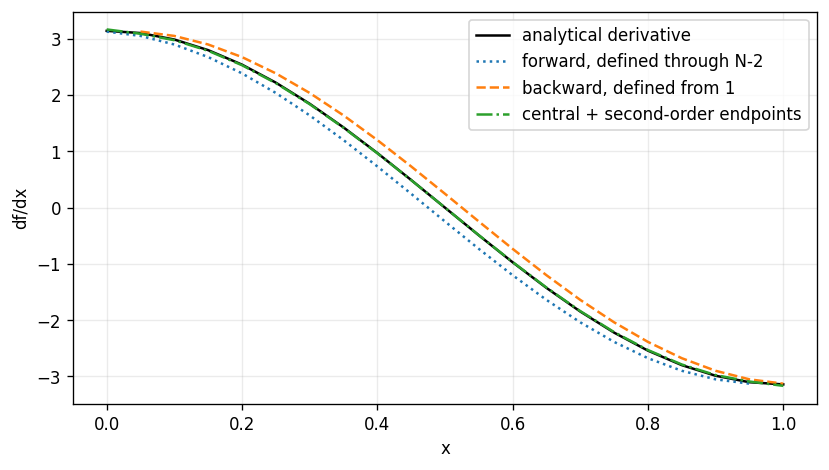

In [17]:
# Every array entry has a defined derivative, including the two endpoints.
# The endpoint formulas below use three values and are second order.
def first_derivatives(f, h):
    f = np.asarray(f, dtype=float)
    if f.ndim != 1 or len(f) < 3 or h <= 0:
        raise ValueError("Supply at least three 1D samples and positive spacing")
    forward = (f[1:] - f[:-1]) / h     # indices 0 ... N-2
    backward = (f[1:] - f[:-1]) / h    # indices 1 ... N-1
    central = np.empty_like(f)
    central[1:-1] = (f[2:] - f[:-2]) / (2*h)
    central[0] = (-3*f[0] + 4*f[1] - f[2]) / (2*h)
    central[-1] = (3*f[-1] - 4*f[-2] + f[-3]) / (2*h)
    return forward, backward, central

N = 21
x = np.linspace(0, 1, N)
h = x[1] - x[0]
f = np.sin(np.pi*x)
exact = np.pi*np.cos(np.pi*x)
forward, backward, central = first_derivatives(f, h)
print(f"N={N}, h={h:.4f}, forward interior at i=1: {forward[1]:.5f}")
print(f"At i=1: (f[2]-f[0])/(2h) = {central[1]:.5f}; exact = {exact[1]:.5f}")
print("Slicing map: f[2:] -> i+1, f[:-2] -> i-1, result -> i=1,...,N-2")
plt.figure(figsize=(7,4))
plt.plot(x, exact, color='black', label='analytical derivative')
plt.plot(x[:-1], forward, ':', label='forward, defined through N-2')
plt.plot(x[1:], backward, '--', label='backward, defined from 1')
plt.plot(x, central, '-.', label='central + second-order endpoints')
plt.xlabel('x'); plt.ylabel('df/dx'); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()


### Grid refinement: measure accuracy rather than eyeballing the curves

Use the same physical interval with $N=11,21,41,81,161$ nodes, so $h=1/(N-1)$ halves each time. Compare errors **only on the interior nodes of each grid (all methods use the same nodes on a given grid)**; the one-sided endpoint formulas belong to a separate boundary check. Here $L_2=\sqrt{\mathrm{mean}(e_i^2)}$ and $L_\infty=\max|e_i|$. If $E(h)\approx Ch^p$, the measured order between two grids is $p=\log(E(h)/E(h/2))/\log2$. When a derivative vanishes at a point, pointwise relative error is misleading; use the absolute norms below.

**Predict:** Which line should fall faster on a log-log plot? Do the forward and backward formulas produce opposite *signed* leading errors?

 N       h         L2 forward   L2 backward   L2 central   Linf central   p_f    p_c
 11  0.100000  3.66410e-01   3.66410e-01    3.42818e-02    4.89059e-02    nan   nan
 21  0.050000  1.78857e-01   1.78857e-01    8.88070e-03    1.27445e-02   1.03  1.95
 41  0.025000  8.83305e-02   8.83305e-02    2.25366e-03    3.21887e-03   1.02  1.98
 81  0.012500  4.38911e-02   4.38911e-02    5.67288e-04    8.06770e-04   1.01  1.99
161  0.006250  2.18772e-02   2.18772e-02    1.42287e-04    2.01821e-04   1.00  2.00


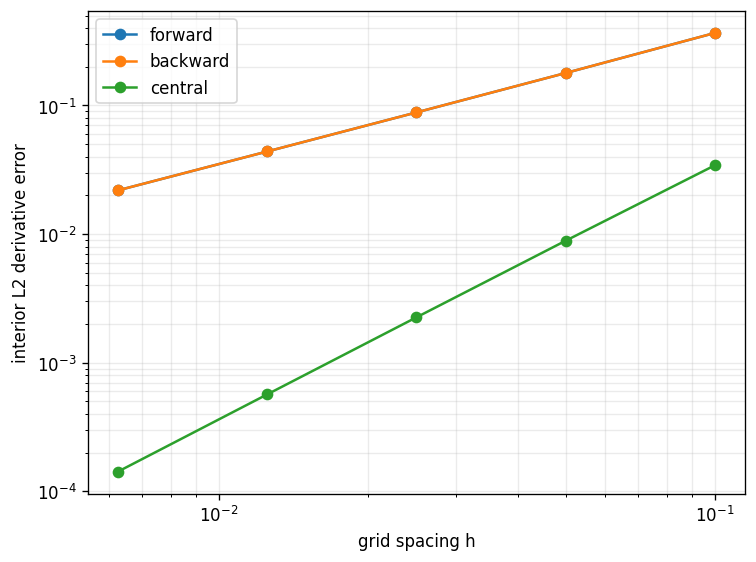

In [18]:
rows = []
for N in [11, 21, 41, 81, 161]:
    x = np.linspace(0, 1, N); h = x[1]-x[0]
    f = np.sin(np.pi*x); truth = np.pi*np.cos(np.pi*x)
    fp, bm, ct = first_derivatives(f, h)
    # Each difference uses its own valid interior positions.
    errors = [fp[1:] - truth[1:-1], bm[:-1] - truth[1:-1], ct[1:-1] - truth[1:-1]]
    rows.append((N, h, *[np.sqrt(np.mean(e**2)) for e in errors],
                 *[np.max(np.abs(e)) for e in errors]))
print(' N       h         L2 forward   L2 backward   L2 central   Linf central   p_f    p_c')
for k, row in enumerate(rows):
    N,h,ef,eb,ec,_,_,einf=row
    pf = np.log2(rows[k-1][2]/ef) if k else float('nan')
    pc = np.log2(rows[k-1][4]/ec) if k else float('nan')
    print(f'{N:3d}  {h:.6f}  {ef:.5e}   {eb:.5e}    {ec:.5e}    {einf:.5e}   {pf:4.2f}  {pc:4.2f}')
for col, label in [(2,'forward'),(3,'backward'),(4,'central')]:
    plt.loglog([r[1] for r in rows], [r[col] for r in rows], 'o-', label=label)
plt.xlabel('grid spacing h'); plt.ylabel('interior L2 derivative error')
plt.grid(True, which='both', alpha=.25); plt.legend(); plt.tight_layout(); plt.show()


### A second known function and the boundary question

Repeat the experiment with $f=e^x$, whose derivative is $e^x$. Its curvature differs from the sine test. The second-order endpoint formulas use $(-3f_0+4f_1-f_2)/(2h)$ and $(3f_{N-1}-4f_{N-2}+f_{N-3})/(2h)$. Central differences need both neighbors, so **never fill an unevaluated boundary with zero and call it a derivative**. Try replacing the endpoint formulas by first-order one-sided differences and compare endpoint error as $N$ changes. For a nonsmooth field or advection-dominated PDE, a central derivative need not give a stable physical solution; order of a smooth derivative test is only one design consideration.

In [19]:
exp_rows = []
for N in [11, 21, 41, 81, 161]:
    x = np.linspace(0, 1, N)
    h = x[1] - x[0]
    exact = np.exp(x)
    _, _, derivative = first_derivatives(exact, h)
    endpoint_error = np.max(np.abs(derivative[[0, -1]] - exact[[0, -1]]))
    interior_error = np.sqrt(np.mean((derivative[1:-1] - exact[1:-1])**2))
    exp_rows.append((N, h, interior_error, endpoint_error))
    print(f'N={N:3d} | interior L2={interior_error:.3e} | endpoint max={endpoint_error:.3e}')
print('Observed endpoint order:', np.log2(exp_rows[-2][3] / exp_rows[-1][3]))


N= 11 | interior L2=2.934e-03 | endpoint max=8.412e-03
N= 21 | interior L2=7.390e-04 | endpoint max=2.182e-03
N= 41 | interior L2=1.855e-04 | endpoint max=5.558e-04
N= 81 | interior L2=4.645e-05 | endpoint max=1.403e-04
N=161 | interior L2=1.162e-05 | endpoint max=3.523e-05
Observed endpoint order: 1.9932489855214854


### The 2D Laplacian: the same idea inside a CFD stencil

For $\phi(x,y)$, $\nabla^2\phi=\phi_{xx}+\phi_{yy}$. On a square grid with $h=\Delta x=\Delta y$,

$$ (L_h\phi)_{j,i}=\frac{\phi_{j,i+1}+\phi_{j,i-1}+\phi_{j+1,i}+\phi_{j-1,i}-4\phi_{j,i}}{h^2}. $$

The four neighbors are east, west, north and south. `phi[j,i]` uses the first index for $y$ and the second for $x$. For $\phi=\sin(\pi x)\sin(\pi y)$ the exact Laplacian is $-2\pi^2\phi$. We compare only interior nodes because this stencil does not evaluate boundary derivatives. This is a **manufactured derivative check**, not validation of the cavity flow.
A **stencil** is the set of neighboring nodes and weights used in an approximation. The next function evaluates only interior nodes. Its `NaN` boundary entries mean “not evaluated”; they are excluded from every error and residual norm.


**Further reading.** MIT OpenCourseWare, [Numerical Methods in Ocean Modeling, Lecture 1](https://ocw.mit.edu/courses/12-950-atmospheric-and-oceanic-modeling-spring-2004/507424ba4dc53db72128cae0d5231e80_lec1.pdf), derives difference formulas from Taylor series. NASA Glenn, [Examining Spatial (Grid) Convergence](https://www.grc.nasa.gov/www/wind/valid/tutorial/spatconv.html), explains how refinement tests observed accuracy. The sine and exponential computations above are local teaching checks; the later cavity benchmark evaluates a separate CFD quantity.


Interior L2 Laplacian error: 2.013e-03


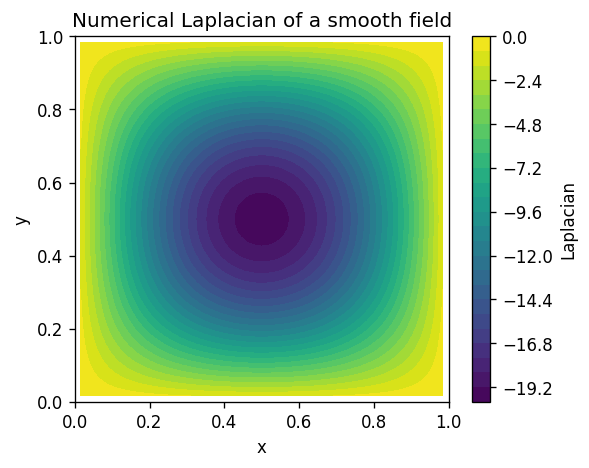

In [20]:
def laplacian_2d(phi, dx):
    # Compute the 2D Laplacian using a five-point finite-difference stencil.
    # Boundary derivatives are undefined and marked NaN in the returned array.
    lap = np.full_like(phi, np.nan, dtype=float)
    lap[1:-1, 1:-1] = (
        phi[1:-1, 2:]     # right neighbor
        + phi[1:-1, :-2]  # left neighbor
        + phi[2:, 1:-1]   # top neighbor
        + phi[:-2, 1:-1]  # bottom neighbor
        - 4.0 * phi[1:-1, 1:-1]
    ) / dx**2
    return lap

N = 65
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]

phi = np.sin(np.pi * X) * np.sin(np.pi * Y)
lap_phi = laplacian_2d(phi, dx)
exact_lap = -2*np.pi**2*phi
interior_error = lap_phi[1:-1,1:-1]-exact_lap[1:-1,1:-1]
print(f"Interior L2 Laplacian error: {np.sqrt(np.mean(interior_error**2)):.3e}")

plt.figure(figsize=(5, 4))
plt.contourf(X, Y, lap_phi, levels=30)
plt.colorbar(label="Laplacian")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerical Laplacian of a smooth field")
plt.tight_layout()
plt.show()

## 10. Boundary conditions: values imposed on the edges

A PDE does not have a unique solution unless boundary conditions are specified.

Common types:

| Boundary condition | Meaning | Example |
|---|---|---|
| Dirichlet | value is specified | $u=0$ at a no-slip wall |
| Neumann | derivative is specified | $\partial T/\partial n=0$ for adiabatic wall |
| Periodic | left and right sides connect | turbulence in a periodic box |

The lid-driven cavity has no-slip walls:
- bottom, left, right walls: $u=v=0$
- top lid: $u=U,\;v=0$

The following function applies a simple lid-driven-cavity velocity boundary condition.
At the two top corners, the moving lid meets stationary walls. This teaching code assigns zero velocity at the corners and lid speed at the other top nodes. This convention is why we report the mean of `u[-1, 1:-1]`, excluding corners.


In [21]:
def apply_cavity_velocity_bc(u, v, lid_speed=1.0):
    # Apply velocity boundary conditions for a lid-driven cavity.

    # Bottom wall
    u[0, :] = 0.0
    v[0, :] = 0.0

    # Top moving lid
    u[-1, :] = lid_speed
    v[-1, :] = 0.0

    # Left wall
    u[:, 0] = 0.0
    v[:, 0] = 0.0

    # Right wall
    u[:, -1] = 0.0
    v[:, -1] = 0.0

    return u, v

u = np.zeros((65, 65))
v = np.zeros((65, 65))
u, v = apply_cavity_velocity_bc(u, v, lid_speed=1.0)

print("top-wall interior u average:", np.mean(u[-1, 1:-1]))
print("left-wall u average:", np.mean(u[:, 0]))

top-wall interior u average: 1.0
left-wall u average: 0.0


## 11. Vectorization: replacing slow loops with array operations

A beginner might compute an update with nested loops:

```python
for j in range(1, Ny-1):
    for i in range(1, Nx-1):
        new[j,i] = ...
```

This is easy to understand, but it is slow for large grids.

NumPy allows vectorized operations over entire slices:

```python
new[1:-1,1:-1] = ...
```

Vectorization is important because:
1. it is faster,
2. it makes the mathematical stencil clearer,
3. it resembles tensor operations in machine learning.

In [22]:
# Compare loop and vectorized versions of a Laplacian update.

N = 100
rng = np.random.default_rng(1)
phi = rng.random((N, N))
dx = 1.0 / (N - 1)

# Loop version
lap_loop = np.zeros_like(phi)
for j in range(1, N - 1):
    for i in range(1, N - 1):
        lap_loop[j, i] = (
            phi[j, i+1] + phi[j, i-1] + phi[j+1, i] + phi[j-1, i]
            - 4.0 * phi[j, i]
        ) / dx**2

# Vectorized version
lap_vec = np.zeros_like(phi)
lap_vec[1:-1, 1:-1] = (
    phi[1:-1, 2:] + phi[1:-1, :-2] + phi[2:, 1:-1] + phi[:-2, 1:-1]
    - 4.0 * phi[1:-1, 1:-1]
) / dx**2

difference = np.max(np.abs(lap_loop - lap_vec))
print(f"Maximum difference between loop and vectorized result = {difference:.3e}")

Maximum difference between loop and vectorized result = 0.000e+00


## 12. A Poisson problem with an exact solution

Choose $\phi_{\mathrm{exact}}=\sin(\pi x)\sin(\pi y)$ on the unit square, so $b=\nabla^2\phi_{\mathrm{exact}}=-2\pi^2\phi_{\mathrm{exact}}$ and $\phi=0$ on all walls. This manufactured problem lets us check our implementation against a known answer.

Insert the five-point stencil into $\nabla^2\phi=b$:

$$\phi_E+\phi_W+\phi_N+\phi_S-4\phi_C=h^2b_C.$$

Solve for the center value, using the previous sweep's values on the right:

$$\phi_C^{k+1}=\tfrac14(\phi_E^k+\phi_W^k+\phi_N^k+\phi_S^k-h^2b_C).$$

The index $k$ counts **Jacobi sweeps**, not physical time. `old = phi.copy()` ensures all updates use the same previous sweep. The zero boundary values remain imposed.

A residual $r=L_h\phi-b$ measures failure to satisfy the **discrete equations**. Solution error $e=\phi-\phi_{\mathrm{exact}}$ measures difference from the **continuum answer**. A tiny residual can coexist with discretization error on a coarse grid. Predict what each curve below will do as the solver converges. A maximum iteration count prevents endless execution; it does not certify convergence.


Sweeps=3817; converged=True; residual=9.964e-09; solution error=8.036e-04


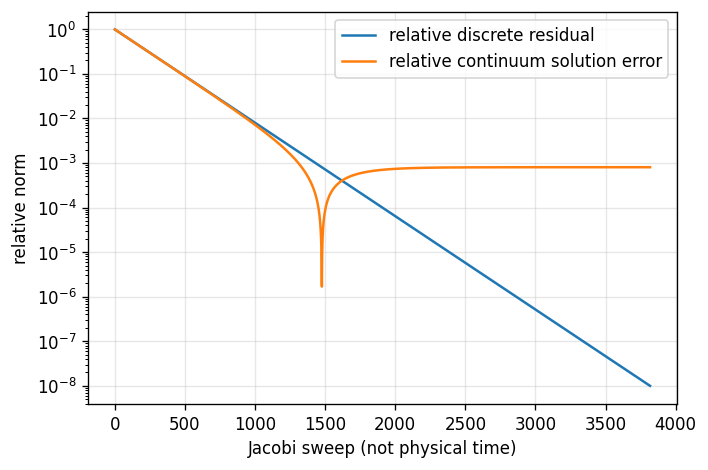

In [23]:
def poisson_jacobi(b, dx, exact, max_iters=6000, tolerance=1e-8):
    phi = np.zeros_like(b)
    residual_history, error_history = [], []
    interior = np.s_[1:-1, 1:-1]
    source_norm = np.linalg.norm(b[interior])
    exact_norm = np.linalg.norm(exact[interior])
    for it in range(1, max_iters + 1):
        old = phi.copy()
        phi[interior] = 0.25 * (
            old[1:-1, 2:] + old[1:-1, :-2]
            + old[2:, 1:-1] + old[:-2, 1:-1]
            - dx**2 * b[interior]
        )
        residual = laplacian_2d(phi, dx)[interior] - b[interior]
        relative_residual = np.linalg.norm(residual) / source_norm
        relative_error = np.linalg.norm(phi[interior] - exact[interior]) / exact_norm
        residual_history.append(relative_residual)
        error_history.append(relative_error)
        if relative_residual < tolerance:
            break
    converged = residual_history[-1] < tolerance
    print(f'Sweeps={it}; converged={converged}; residual={relative_residual:.3e}; solution error={relative_error:.3e}')
    if not converged:
        raise RuntimeError('Poisson solve did not meet the requested residual tolerance')
    return phi, np.array(residual_history), np.array(error_history)

N = 33
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
exact_phi = np.sin(np.pi*X) * np.sin(np.pi*Y)
b = -2*np.pi**2 * exact_phi
phi, residuals, solution_errors = poisson_jacobi(b, dx, exact_phi)
plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(1, len(residuals)+1), residuals, label='relative discrete residual')
plt.semilogy(np.arange(1, len(solution_errors)+1), solution_errors, label='relative continuum solution error')
plt.xlabel('Jacobi sweep (not physical time)')
plt.ylabel('relative norm'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()


### What did we just learn?

The residual falls below the requested tolerance, while the error relative to the analytic solution ultimately levels off at the grid's discretization error. The solution error may briefly dip before settling: iteration error and discretization error can partially cancel. A small error at one intermediate sweep is not a sound stopping criterion.

**Try it:** use `N=17`, then restore `N=33`. Compare the final solution errors at the same residual tolerance. Why do more Jacobi sweeps on one grid eventually stop improving the continuum error? Explain which change reduces iteration error and which reduces spatial discretization error.


## 13. Time marching: from the diffusion PDE to a time loop

The 1D diffusion equation is

$$u_t=\nu u_{xx}.$$

In a simple shear flow it describes viscous smoothing of a velocity profile; $\nu$ is kinematic viscosity. Let $u_i^n=u(x_i,t_n)$ with $t_n=n\Delta t$. Apply a forward difference **in time** and a central second derivative **in space**:

$$\frac{u_i^{n+1}-u_i^n}{\Delta t}=\nu\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{h^2}.$$

Rearranging gives the line used in the loop:

$$u_i^{n+1}=u_i^n+r(u_{i+1}^n-2u_i^n+u_{i-1}^n),\qquad r=\nu\Delta t/h^2.$$

The method is first order in time and second order in space for smooth solutions. For this uniform-grid 1D diffusion problem, $0\le r\le1/2$ is the explicit stability restriction. It makes the update a weighted average with weights $r,1-2r,r$. If you halve $h$ at fixed $\nu$, you must reduce $\Delta t$ by a factor of four to retain the same $r$.

First observe a square pulse smoothing with zero wall values. The pulse is initially discontinuous, so it is a qualitative demonstration, not a smooth-function order test. The following sine-mode experiment supplies an exact solution for quantitative accuracy.


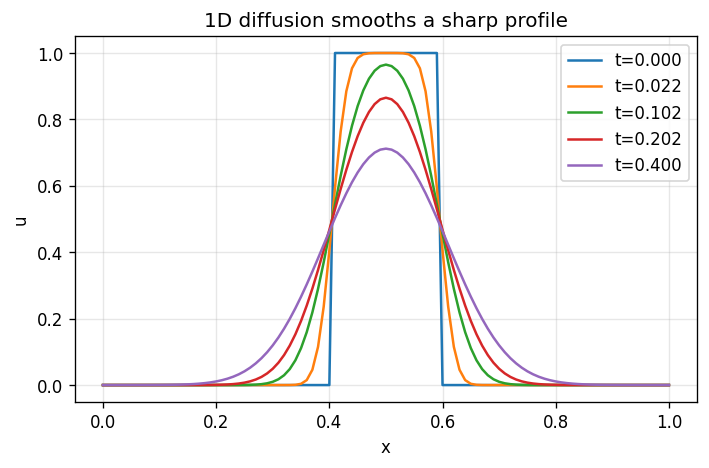

In [24]:
# 1D diffusion example

N = 101
x = np.linspace(0, 1, N)
dx = x[1] - x[0]
nu = 0.01
dt = 0.2 * dx**2 / nu  # safe explicit time step
steps = 200

u = np.zeros(N)
u[(x > 0.4) & (x < 0.6)] = 1.0  # square pulse

history = [(0.0, u.copy())]

for step in range(steps):
    old = u.copy()
    u[1:-1] = old[1:-1] + nu * dt / dx**2 * (old[2:] - 2*old[1:-1] + old[:-2])

    # Dirichlet boundaries
    u[0] = 0.0
    u[-1] = 0.0

    if step in [10, 50, 100, 199]:
        history.append(((step + 1)*dt, u.copy()))

plt.figure(figsize=(6, 4))
for time, profile in history:
    plt.plot(x, profile, label=f"t={time:.3f}")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D diffusion smooths a sharp profile")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Quantitative diffusion check at the same physical time

Set $u(x,0)=\sin(\pi x)$ and $u(0,t)=u(1,t)=0$. The exact answer is

$$u_{\mathrm{exact}}(x,t)=e^{-\nu\pi^2t}\sin(\pi x).$$

Substitution verifies that $u_t=-\nu\pi^2u$ and $\nu u_{xx}=-\nu\pi^2u$. Every grid below stops at **the same final time**, $T=0.1$, rather than the same number of steps. The last adjustment sets $\Delta t=T/n_{\mathrm{steps}}$ so there is no final-time mismatch.

We measure interior RMS error and maximum absolute error. Because $\Delta t\propto h^2$, both the $O(\Delta t)$ time error and $O(h^2)$ spatial error decrease at order two with $h$ in this experiment. This does **not** make forward Euler second order in time, and this manufactured test is not experimental validation of the cavity flow.


 N       h         dt        steps    RMS error   max error   p_obs
 11  0.10000  2.000e-02       5   1.093e-04   1.466e-04   nan
 21  0.05000  5.000e-03      20   2.666e-05   3.674e-05   2.035
 41  0.02500  1.250e-03      80   6.582e-06   9.191e-06   2.018
 81  0.01250  3.125e-04     320   1.635e-06   2.298e-06   2.009
161  0.00625  7.813e-05    1280   4.076e-07   5.746e-07   2.004


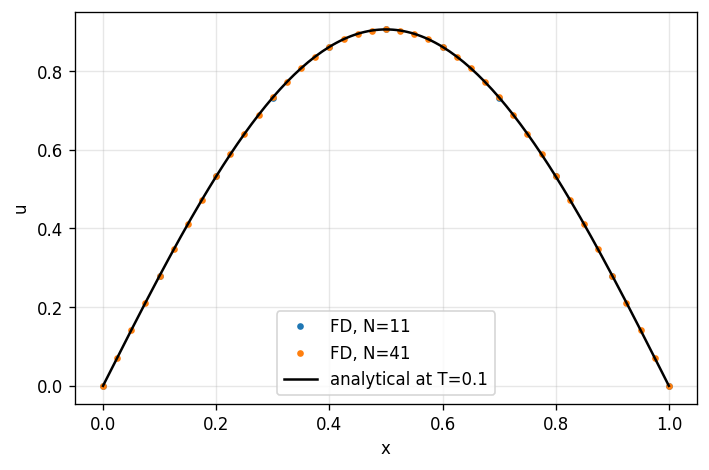

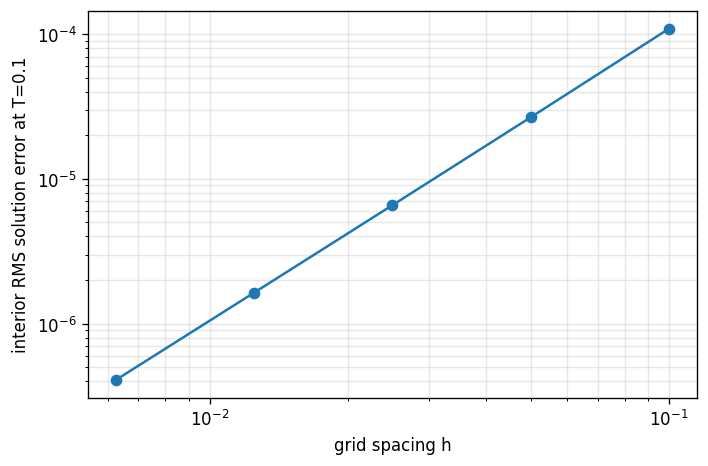

In [25]:
def diffusion_sine(N, final_time=0.1, nu=0.1, target_r=0.2):
    x = np.linspace(0, 1, N)
    h = x[1] - x[0]
    steps = int(np.ceil(final_time / (target_r*h*h/nu)))
    dt = final_time / steps
    r = nu*dt/h**2
    u = np.sin(np.pi*x)
    u[[0, -1]] = 0.0
    for _ in range(steps):
        old = u.copy()
        u[1:-1] = old[1:-1] + r*(old[2:] - 2*old[1:-1] + old[:-2])
    exact = np.exp(-nu*np.pi**2*final_time)*np.sin(np.pi*x)
    error = u[1:-1] - exact[1:-1]
    return x, u, exact, h, dt, steps, np.sqrt(np.mean(error**2)), np.max(np.abs(error))

diffusion_rows = []
plt.figure(figsize=(6, 4))
print(' N       h         dt        steps    RMS error   max error   p_obs')
for N in [11, 21, 41, 81, 161]:
    x, u, exact, h, dt, steps, rms, maximum = diffusion_sine(N)
    order = np.log2(diffusion_rows[-1][1]/rms) if diffusion_rows else float('nan')
    diffusion_rows.append((h, rms, maximum))
    print(f'{N:3d}  {h:.5f}  {dt:.3e}   {steps:5d}   {rms:.3e}   {maximum:.3e}   {order:.3f}')
    if N in [11, 41]:
        plt.plot(x, u, 'o', markersize=3, label=f'FD, N={N}')
plt.plot(x, exact, '-', color='black', label='analytical at T=0.1')
plt.xlabel('x'); plt.ylabel('u'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
plt.figure(figsize=(6, 4))
plt.loglog([row[0] for row in diffusion_rows], [row[1] for row in diffusion_rows], 'o-')
plt.xlabel('grid spacing h'); plt.ylabel('interior RMS solution error at T=0.1')
plt.grid(True, which='both', alpha=.3); plt.tight_layout(); plt.show()


**Explain your result:** Why compare at one final physical time? What happened to the required number of time steps when the mesh was refined? Why is an order near two in this table consistent with a first-order time integrator?


## 14. A tiny machine-learning-style example using only NumPy

Before TensorFlow, it is useful to understand the basic structure of learning:

1. choose a model,
2. make predictions,
3. compute a loss,
4. update parameters,
5. repeat.

This is similar to CFD iteration:

| CFD | Machine learning |
|---|---|
| unknown field | model parameters |
| PDE residual | loss |
| iteration/time step | epoch |
| convergence history | training-loss history |

Here we fit a line $y=ax+b$ using gradient descent.

Learned a = 2.005
Learned b = 0.499


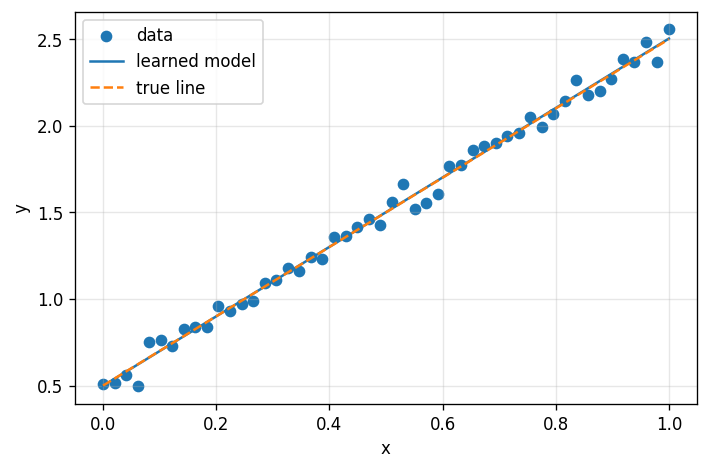

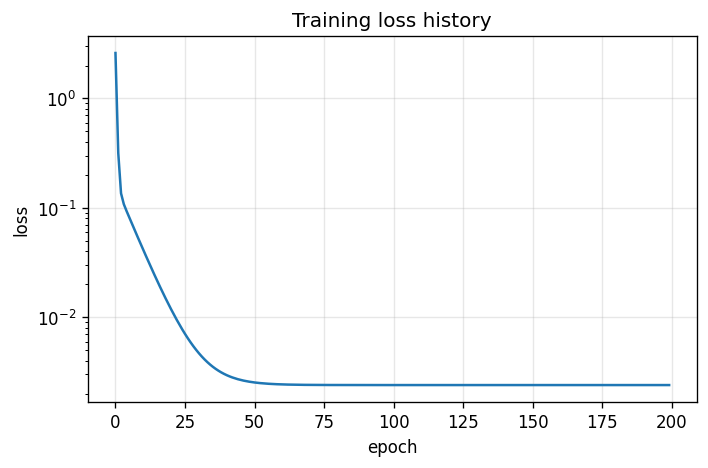

In [26]:
# Generate synthetic data
rng = np.random.default_rng(2)
x_data = np.linspace(0, 1, 50)
y_true = 2.0 * x_data + 0.5
y_data = y_true + 0.05 * rng.normal(size=x_data.shape)

# Initial model parameters
a = 0.0
b = 0.0
learning_rate = 0.5
loss_history = []

for epoch in range(200):
    y_pred = a * x_data + b
    error = y_pred - y_data
    loss = np.mean(error**2)
    loss_history.append(loss)

    # Gradients of mean squared error
    grad_a = 2.0 * np.mean(error * x_data)
    grad_b = 2.0 * np.mean(error)

    # Parameter update
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b

print(f"Learned a = {a:.3f}")
print(f"Learned b = {b:.3f}")

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, label="data")
plt.plot(x_data, a*x_data + b, label="learned model")
plt.plot(x_data, y_true, "--", label="true line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.semilogy(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss history")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. How this prepares you for the lid-driven cavity CFD code

The Ghia cavity solver will look more complicated, but it uses the same ideas:

| This notebook | Cavity code |
|---|---|
| `N`, `dx`, `dt`, `Re` | grid spacing, time step, Reynolds number |
| 2D arrays | streamfunction, vorticity, velocity |
| finite differences | derivatives in Navier--Stokes |
| boundary slices | no-slip wall conditions |
| loops | time marching and Poisson iterations |
| residual history | convergence to steady state |
| validation plot | comparison with Ghia et al. |

The student should now be able to open the cavity solver and identify:
- where the grid is created,
- where the boundary conditions are applied,
- where derivatives are computed,
- where iterations happen,
- where errors against benchmark data are calculated.

## 16. Required student deliverables for this Python warmup

Submit a short PDF or notebook export containing:

1. Your Reynolds-number calculation and one sentence explaining what happens when viscosity decreases.
2. Your `if/elif/else` grid classifier.
3. Your forward, backward and central derivative plots, refinement table with observed orders, and a sentence explaining why central differences are used in the smooth interior.
4. The manufactured 2D Laplacian interior error and how boundaries were handled.
5. A plot of the Poisson residual history.
6. The diffusion profiles at labeled times and the sine-mode grid-refinement table, with an explanation of space versus time accuracy.
7. A short paragraph distinguishing derivative error, solver residual and comparison with an independent CFD benchmark.

This is a programming assignment, not just a clicking assignment.  
Your code must run, but your explanations are equally important.

## Article-output contract

<!-- MIE690A article-aligned validation v3 -->

**Role:** Foundational or supporting notebook; see ARTICLE_FIGURE_MAP.md for its evidence dependency.

All manuscript-facing figures must be generated from retained numerical/model outputs through the documented notebook or shared helper, saved under `results/`, and accompanied by machine-readable metrics. Do not redraw curves by eye or substitute a screenshot for a solver-to-reference comparison. The complete ownership table and exact output filenames are in [`ARTICLE_FIGURE_MAP.md`](../../ARTICLE_FIGURE_MAP.md).
